**K-Means vs. DBSCAN: Choosing the Right Clustering Algorithm**
-
* **Name/s:** Enrico Miguel Veloso, John Dennis Vergara, Shane Hans Uy
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 4/18/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** K-Means vs. DBSCAN: Choosing the Right Clustering Algorithm
* **Dataset:** Credit Card Dataset for Clustering (CC General)
* **Abstract:** This notebook examines credit card usage behaviors using key financial variables. Analysis shows skewed distributions suggesting the diverse customer profiles and outliers. The selected key features provide valuable insights for credit risk assessment and decision-making.
----

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from IPython.core.pylabtools import figsize
from debugpy.launcher.debuggee import describe
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
import warnings
from sklearn.neighbors import NearestNeighbors
from sympy.physics.units import frequency

warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Set seed:
random.seed(16)

**1. Data Preparation**
- 

In [32]:
#Load the dataset:
df = pd.read_csv(r"CC GENERAL.csv")
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


- The dataset shows different credit card usage behaviors per customer; the dataset provides a basis for segmentation and risk profiling.

In [33]:
#Select six features (BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS): (Code idea generated by DeepSeek)
selected_feat = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

#Before
rows_before = df[selected_feat].shape[0]

#Select and clean
df_selected_feat = df[selected_feat].copy()
df_selected_feat = df_selected_feat.dropna()

#After
rows_after = df_selected_feat.shape[0]

print("Rows removed due to missing values:", rows_before - rows_after)

Rows removed due to missing values: 314


- 314 rows are removed from the dataset due to missing values.

In [34]:
df_selected_feat.head(5)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,40.900749,95.40,0.000000,1000.0,201.802084,139.509787
1,3202.467416,0.00,6442.945483,7000.0,4103.032597,1072.340217
2,2495.148862,773.17,0.000000,7500.0,622.066742,627.284787
4,817.714335,16.00,0.000000,1200.0,678.334763,244.791237
5,1809.828751,1333.28,0.000000,1800.0,1400.057770,2407.246035


- The six selected features are BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, and MINIMUM_PAYMENTS. The variables selected are suitable for multivariate analysis to identify customer segments.

In [35]:
#Check dataframe with the six feature selected shape: (Code copied from previous assessments)
df_selected_feat_shape = df_selected_feat.shape
print("Dataframe shape:")
print("=" * 16)
print("Total number of rows:", df_selected_feat_shape[0])
print("Total number of columns:", df_selected_feat_shape[1])

Dataframe shape:
Total number of rows: 8636
Total number of columns: 6


In [36]:
#Descriptive statistics of the dataset: (Code copied from previous assessments)
df_selected_feat.describe()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,1025.433874,994.175523,4522.091030,1784.478099,864.304943
std,2095.571300,2167.107984,2121.458303,3659.240379,2909.810090,2372.566350
min,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163
25%,148.095189,43.367500,0.000000,1600.000000,418.559237,169.163545
50%,916.855459,375.405000,0.000000,3000.000000,896.675701,312.452292
75%,2105.195853,1145.980000,1132.385490,6500.000000,1951.142090,825.496463
max,19043.138560,49039.570000,47137.211760,30000.000000,50721.483360,76406.207520


- Descriptive statistics for the selected features. The features show a positive skew, which indicates the presence of outliers; therefore, scaling is required.

In [37]:
#Check for missing or null values: (Code copy from previous assessments)
print("Total count of null values of each column/feature:")
print("=" * 50)
df_selected_feat.isnull().sum()

Total count of null values of each column/feature:


BALANCE             0
PURCHASES           0
CASH_ADVANCE        0
CREDIT_LIMIT        0
PAYMENTS            0
MINIMUM_PAYMENTS    0
dtype: int64

In [38]:
#Remove missing values: (Code copy from previous assesments):
df_selected_feat = df_selected_feat.dropna()

print("Total count of null values of each column/feature after removing all null values:")
print("=" * 81)
df_selected_feat.isnull().sum()

Total count of null values of each column/feature after removing all null values:


BALANCE             0
PURCHASES           0
CASH_ADVANCE        0
CREDIT_LIMIT        0
PAYMENTS            0
MINIMUM_PAYMENTS    0
dtype: int64

In [39]:
#Scale values for each feature: (Code copied from previous assessments)
scaler = StandardScaler()
df_selected_feat_scaled = scaler.fit_transform(df_selected_feat)
df_selected_feat_scaled = pd.DataFrame(df_selected_feat_scaled, columns = df_selected_feat.columns)
df_selected_feat_scaled.head(5)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,-0.744625,-0.429184,-0.468655,-0.962575,-0.543942,-0.305508
1,0.764152,-0.473208,2.568556,0.677204,0.796852,0.087689
2,0.426602,-0.116413,-0.468655,0.813852,-0.399503,-0.099906
3,-0.373910,-0.465825,-0.468655,-0.907916,-0.380165,-0.261131
4,0.099551,0.142062,-0.468655,-0.743938,-0.132119,0.650363


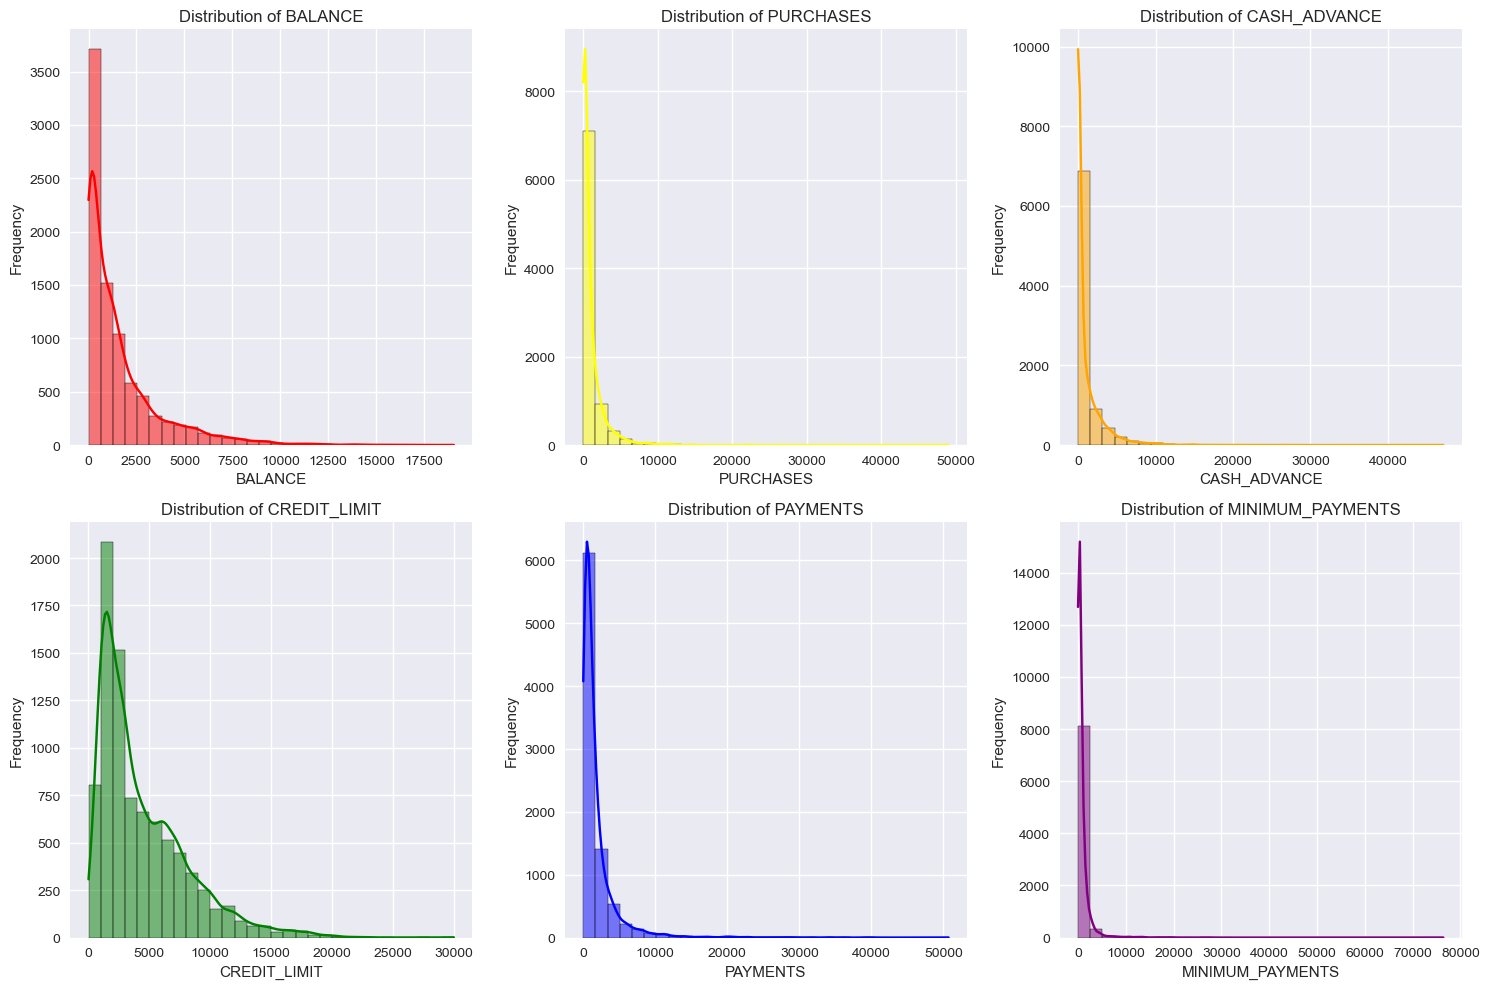

In [40]:
#Plot each distribution of each feature: (AI generated and assisted from DeepSeek)
colors_dist = ['red', 'yellow', 'orange', 'green', 'blue', 'purple']
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()
features = df_selected_feat.columns

for i, col in enumerate(features):
    sns.histplot(df_selected_feat[col], kde = True, ax = axes[i], bins = 30, color = colors_dist[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

---
* The majority of the features and their distributions are right-skewed.
* The frequency of values for each feature is mostly concentrated at lower values or equal to zero.
* There are potential outliers in every distribution; since they are all right-skewed, certain data points possess significantly larger values than the rest.
---

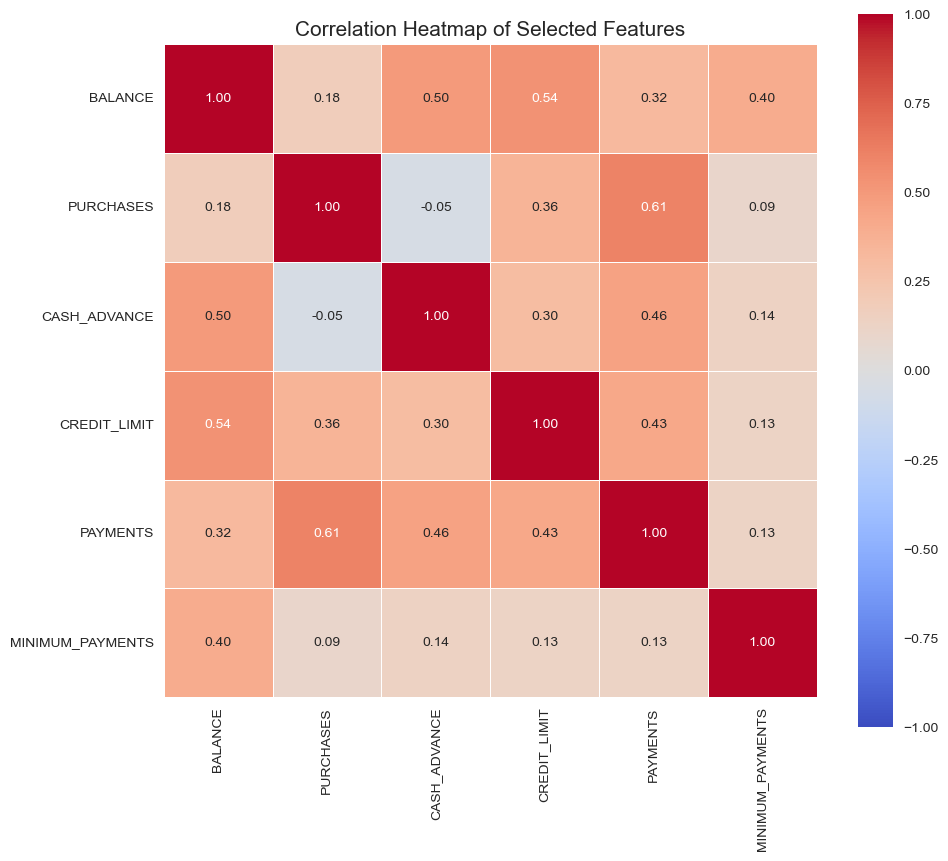

In [41]:
#Correlation heatmap: (AI generated and assisted from DeepSeek)
corr_matrix = df_selected_feat.corr()
plt.figure(figsize = (10, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Selected Features', fontsize = 15)
plt.tight_layout()
plt.show()

---
* **Significant relationships based from the given correlation heat map that have a significant positive or negative correlation:**
  * **_BALANCE & CASH_ADVANCE_** = 0.50 [Strong Positive]
  * **_BALANCE & CREDIT_LIMIT_** = 0.54 [Strong Positive]
  * **_PURCHASES & PAYMENTS_** = 0.61 [Strong Positive]
* **Customer groups develop based from the given correlation heat map:**
  * Customer according to the following:
    * BALANCE | PAYMENTS | PURCHASES | CREDIT_LIMIT | CASH_ADVANCE
---
* The relationships obesrved from the following only revolves around the following features from the six and that is BALANCE, PAYMENTS, PURCHASES, CASH_ADVANCE, and CREDIT_LIMIT since all of which along with with their relationships achieve a strong positive correlation which denotes significance in relation between two features. In addition, besides relationship significance between different features, potential groups or categories of customers that we could find is also based from the mentioned features previously.
---

**2. K-Means Clustering**
-

In [42]:
#Use the elbow method and silhouette analysis to choose K: (AI generated and assisted from DeepSeek)
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    k_means = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = k_means.fit_predict(df_selected_feat_scaled)
    inertias.append(k_means.inertia_)
    sil_scores.append(silhouette_score(df_selected_feat_scaled, labels))

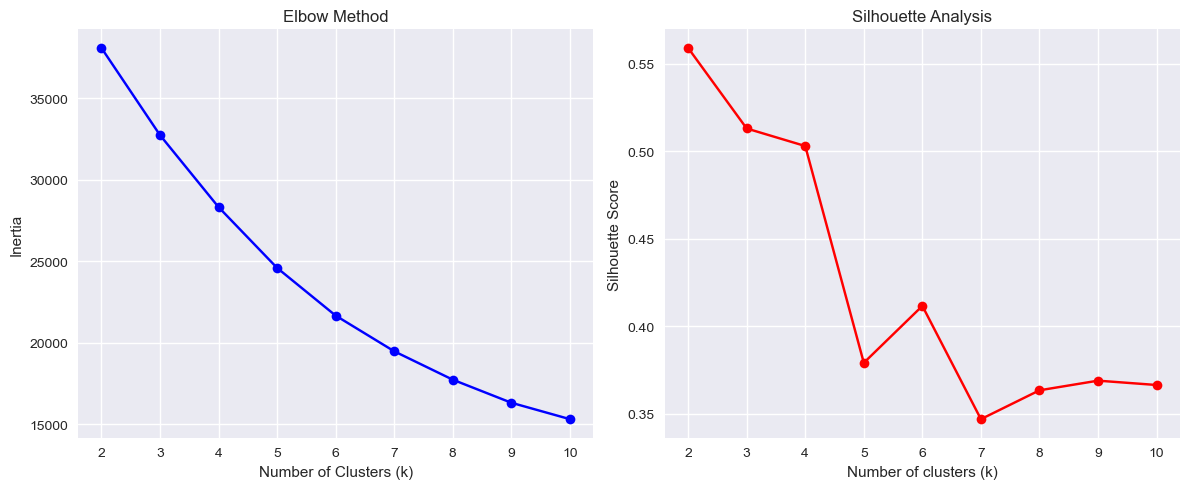

In [43]:
#Plot both curves and justify your final choice: (AI generated and assisted from DeepSeek)
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.tight_layout()
plt.show()

---
**Based on the plotted graphs for the Elbow Method and Silhouette analysis the best (K) from both of the models is K = 3 due to the following reasons:**

- For the elbow method, starting from the lowest value of K = 2 from that point the gap of decrease in variation is significant and it stops at K = 3 which from there the sharpness of the decreasing slope decreases and curves as the value of (K) increases and this denotes the "elbow" point of the graph.
- For the sihouette analysis plot, from the lowest value of K =  2 it achieved the highest silhouette score which denotes that the best K = 2 and the other best option for K = 3 which it the 2nd best silhouette score besides from K = 2. In short, for silhouette analysis we could considere two (k) values.
- Since both models agree that K = 3 is the best value for (K), the chosen (K) value will be the number of clusters that will represent the number of groups or categories that model would try to categorize.
---

In [44]:
#Fit K-Means with your chosen K: (AI generated and assisted from DeepSeek)
best_k = 3
k_means_final = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
cluster_labels = k_means_final.fit_predict(df_selected_feat_scaled)
df_selected_feat["Cluster"] = cluster_labels
df_selected_feat["Cluster"].value_counts().sort_index()

Cluster
0    6974
1    1537
2     125
Name: count, dtype: int64

In [45]:
#Report the silhouette score, Davies-Bouldin index, and Calinski-Harabasz index: (AI generated and assisted from DeepSeek)
sil_avg = silhouette_score(df_selected_feat_scaled, cluster_labels)
db_indx = davies_bouldin_score(df_selected_feat_scaled, cluster_labels)
ch_indx = calinski_harabasz_score(df_selected_feat_scaled, cluster_labels)

print(f"Silhouette Score: {sil_avg:.3f}")
print(f"Davies-Bouldin Index: {db_indx:.3f}")
print(f"Calinski-Harabasz Index: {ch_indx:.3f}")

Silhouette Score: 0.513
Davies-Bouldin Index: 1.283
Calinski-Harabasz Index: 2515.280


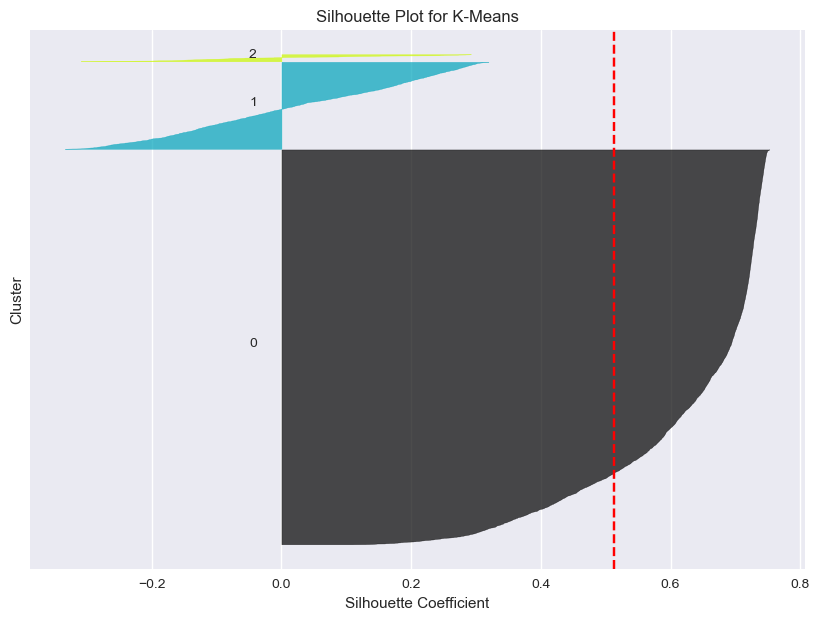

In [46]:
#Produce a silhouette plot: (AI generated and assisted from DeepSeek)
fig, ax = plt.subplots(figsize=(10, 7))
sil_vals = silhouette_samples(df_selected_feat_scaled, cluster_labels)
y_lower = 10
for i in range(best_k):
    ith_sil_vals = sil_vals[cluster_labels == i]
    ith_sil_vals.sort()
    y_upper = y_lower + len(ith_sil_vals)
    color = plt.cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(ith_sil_vals), str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for K-Means')
ax.set_yticks([])
plt.show()

In [47]:
#Present cluster centroids in original units and describe each cluster in one sentence: (AI generated and assisted from DeepSeek)
centroids_scaled = k_means_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns = df_selected_feat.columns[:-1])
centroids_df.index.name = "Cluster"
centroids_df

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
Cluster,,,,,,
0,853.71602,764.117148,449.706936,3407.305062,1155.988360,480.118948
1,4725.85183,1383.896792,3117.906628,8923.931523,3304.168991,2476.719449
2,4792.89586,11182.281920,5193.732493,12460.800000,18111.502079,2424.642761


---
* **Cluster#1 (initially 0 since it follows the index):** Low usage, inactive or minimal customers. Customers that barely uses his/her credit card or have set their credit to a minimum.
* **Cluster#2 (initially 1 since it follows the indes):** High balance, cash-advance users with moderate payments. Somehow similar to the third cluster but not as much of a heavy spender.
* **Clueter#3 (initially 2 since it follows the index):** High spending with very high payments. Customers that have a high credit limit has can cash-advance at a large amount.
---

**3. DBSCAN Clustering**
-

***STEP 1: K-Distance Plot for eps Selection***

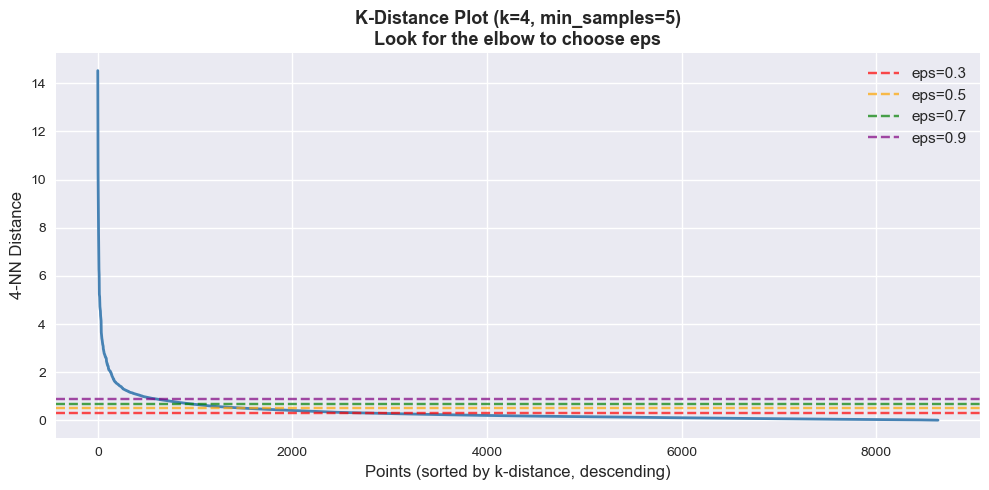

Reading the plot:
  The 'elbow' is where the curve bends sharply.
  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.

  We'll test eps = 0.3, 0.5, and 0.7 to see how the results change.


In [48]:
min_samples = 5
k = min_samples - 1  # k-distance uses k = min_samples - 1

# Fit nearest neighbors
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(df_selected_feat_scaled)  # +1 because point counts itself
distances, _ = nbrs.kneighbors(df_selected_feat_scaled)

# Get the k-th neighbor distance for each point (last column)
k_distances = np.sort(distances[:, -1])[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=2)
ax.set_xlabel('Points (sorted by k-distance, descending)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.set_title(
    f'K-Distance Plot (k={k}, min_samples={min_samples})\nLook for the elbow to choose eps',
    fontsize=13,
    fontweight='bold'
)

# Annotate candidate eps values
for eps_candidate, color, label in [
    (0.3, 'red', 'eps=0.3'),
    (0.5, 'orange', 'eps=0.5'),
    (0.7, 'green', 'eps=0.7'),
    (0.9, 'purple', 'eps=0.9')
]:
    ax.axhline(y=eps_candidate, color=color, linestyle='--', alpha=0.7, label=label)

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Reading the plot:")
print("  The 'elbow' is where the curve bends sharply.")
print("  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.")
print()
print("  We'll test eps = 0.3, 0.5, and 0.7 to see how the results change.")

---
***STEP 2: eps Sensitivity Analysis***

In [49]:
eps_values = [0.2, 0.3, 0.5, 0.7, 1.0]
results = []

print(f"{'eps':>6}  |  {'Clusters':>9}  |  {'Noise pts':>10}  |  {'Noise %':>8}  |  {'Silhouette':>12}")
print("-" * 60)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(df_selected_feat_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(df_selected_feat_scaled[mask], labels[mask]) if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')

    results.append({
        'eps': eps,
        'clusters_found': n_clusters,
        'noise_points': n_noise,
        'noise_percentage': noise_pct,
        'silhouette': sil
    })

    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "N/A"
    print(f"  {eps:>4}  |  {n_clusters:>9}  |  {n_noise:>10}  |  {noise_pct:>7.1f}%  |  {sil_str:>12}")

# -----------------------------------------------------------------------------
# FINAL PARAMETERS
# -----------------------------------------------------------------------------
final_eps = 0.7
final_min_samples = min_samples

print("\nFinal Parameters:")
print(f"  eps = {final_eps}")
print(f"  min_samples = {final_min_samples}")

   eps  |   Clusters  |   Noise pts  |   Noise %  |    Silhouette
------------------------------------------------------------
   0.2  |         32  |        3596  |     41.6%  |       -0.3000
   0.3  |         21  |        2417  |     28.0%  |       -0.0799
   0.5  |          9  |        1206  |     14.0%  |        0.2591
   0.7  |          6  |         735  |      8.5%  |        0.3780
   1.0  |          4  |         309  |      3.6%  |        0.6076

Final Parameters:
  eps = 0.7
  min_samples = 5


**Key Insights:** Based from the table above, eps = `0.2` and `0.3` is too small and creates excessive noise which indicating many tiny clusters. On the other hand, `eps = 1.0` is too large and only produces 4 clusters indicating over-merging of groups leading to loss of structure.

`eps = 0.7`, however provides the best balance in terms of clusters (6), noise points (735), noise percentage (8.5%), and yielded a decent sillhouette score (0.3780).

Therefore, the final parameters selected are **eps = 0.7** and **min_samples = 5**.

---

***STEP 3: Fit DBSCAN with the chosen parameters.***

Final DBSCAN (eps=0.7, min_samples=5)
  Clusters found  : 6
  Noise points    : 735 (8.5%)

Cluster sizes:
    Noise (-1): 735 points (8.5%)
     Cluster 0: 7874 points (91.2%)
     Cluster 1: 7 points (0.1%)
     Cluster 2: 6 points (0.1%)
     Cluster 3: 8 points (0.1%)
     Cluster 4: 5 points (0.1%)
     Cluster 5: 1 points (0.0%)


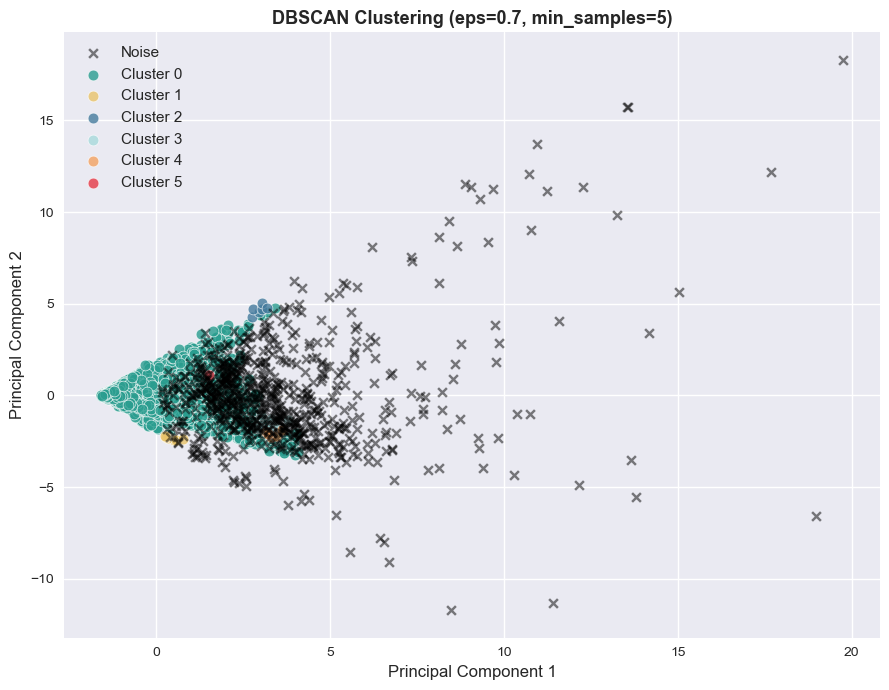

In [50]:
from sklearn.decomposition import PCA

eps_final = 0.7
db_final = DBSCAN(eps=eps_final, min_samples=min_samples).fit(df_selected_feat_scaled)
df_selected_feat['DBSCAN_Cluster'] = db_final.labels_

labels = db_final.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"Final DBSCAN (eps={eps_final}, min_samples={min_samples})")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print()
print("Cluster sizes:")
for lbl in sorted(set(labels)):
    count = (labels == lbl).sum()
    name = f"Cluster {lbl}" if lbl != -1 else "Noise (-1)"
    print(f"  {name:>12}: {count} points ({count/len(labels)*100:.1f}%)")

# Visualization
# Reduce the scaled multi-feature data into 2D for plotting
X_vis = PCA(n_components=2, random_state=42).fit_transform(df_selected_feat_scaled)

palette = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#a8dadc', '#f4a261']

fig, ax = plt.subplots(figsize=(9, 7))

for i, lbl in enumerate(sorted(set(labels))):
    mask = labels == lbl
    if lbl == -1:
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1], c='black', s=40, alpha=0.5,
                   marker='x', zorder=5, label='Noise')
    else:
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1], color=palette[i % len(palette)],
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=f'Cluster {lbl}')

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title(f'DBSCAN Clustering (eps={eps_final}, min_samples={min_samples})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
***STEP 4: Validation Metrics.***

In [51]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

mask = labels != -1
X_non_noise = df_selected_feat_scaled[mask]
labels_non_noise = labels[mask]

if len(set(labels_non_noise)) >= 2:
    sil = silhouette_score(X_non_noise, labels_non_noise)
    dbi = davies_bouldin_score(X_non_noise, labels_non_noise)
    chi = calinski_harabasz_score(X_non_noise, labels_non_noise)

    print("Validation Metrics (Non-Noise Points Only):")
    print(f"  Silhouette Score        : {sil:.4f}")
    print(f"  Davies-Bouldin Index    : {dbi:.4f}")
    print(f"  Calinski-Harabasz Index : {chi:.4f}")
else:
    print("Not enough clusters to compute validation metrics.")

Validation Metrics (Non-Noise Points Only):
  Silhouette Score        : 0.3780
  Davies-Bouldin Index    : 0.4797
  Calinski-Harabasz Index : 63.4999



***STEP 5: Profile Each Cluster and Noise Points Separately***

In [52]:
print("\nCluster / Noise Profile (Mean Values):")
cluster_profile = df_selected_feat.groupby('DBSCAN_Cluster')[selected_feat].mean().round(2)
display(cluster_profile)


Cluster / Noise Profile (Mean Values):


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
DBSCAN_Cluster,,,,,,
-1,4896.44,3655.72,3854.63,9795.92,7366.00,3844.70
0,1288.79,773.92,715.59,4025.04,1249.31,574.80
1,1735.92,276.03,175.64,1871.43,141.44,13369.82
2,857.84,11317.99,145.93,5500.00,11376.81,234.50
3,5084.49,242.30,7895.23,7562.50,7200.41,1310.65
4,4358.96,234.76,10544.24,8000.00,5541.44,1288.43
5,1563.49,1910.13,0.00,13000.00,5142.62,425.20


`Noise Points (-1):` The noise points represents the customers with high value across all the features. This indicates abnormal financial behavior. These customers are considered as the outliers among the other customers.

`Cluster (0):` This cluster consists of customers with a relatively low balance (ranked second to the lowest amongst the other clusters). These customers however have low purchases and a relatively low credit limit.

`Cluster (1):` Cluster 1 consists of customers with a moderate balance (1735.92), paired with low purchases, cash_advance, credit limit and payments. However, this cluster shows an unusually high minimum payments. This could indicate a possible recent payment of debt.

`Cluster (2):` Cluster 2 consists of customer with a very low balance, but has high purchases, payments and a moderate credit limit. In addition, they also have low minimum payments. This indicates that they dont accumulate large oustanding balances since purchases and payments are almost equal.

`Cluster (3):` Cluster 3 involves customers with high balance, low purchases, very high cash advance, high payments, and a moderate minimum payments. These values indicate that they dont use the card for regular spending but rather on cash advance. Moreover, they also have high payments but sill has a relatively high balance, indicating that they payments are not enough.

`Cluster (4):` Cluster 4 consists of customers with high balance, low purchases, extermely high cash advance, high credit limit, moderately high payments, and a moderate minimum payments. This cluster is similar to cluster 3 but has a much higher cash advance, paired with high balance. Moreover, this cluster has low purchases indicating that the card is not used on regular payments. It also has a moderately high payments but sill has a high balance.

`Cluster (5):` Cluster 5 consists of customers with a moderate balance, moderate purchases, no cash advance, high credit limit, high payments and low minimum payments. This indicates that these customers use their card but not excessively. They are most likelu trusted users due to their high credit limit paried with high payments.

---

**4. Comparison & Recommendation**
-

**1: Fitting the models**

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected_feat)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

---
- The data was fitted and standardized to make sure that the features are equal in distance calculations.
---

**2: Scatter Plot Comparison (Balance VS Purchases)**

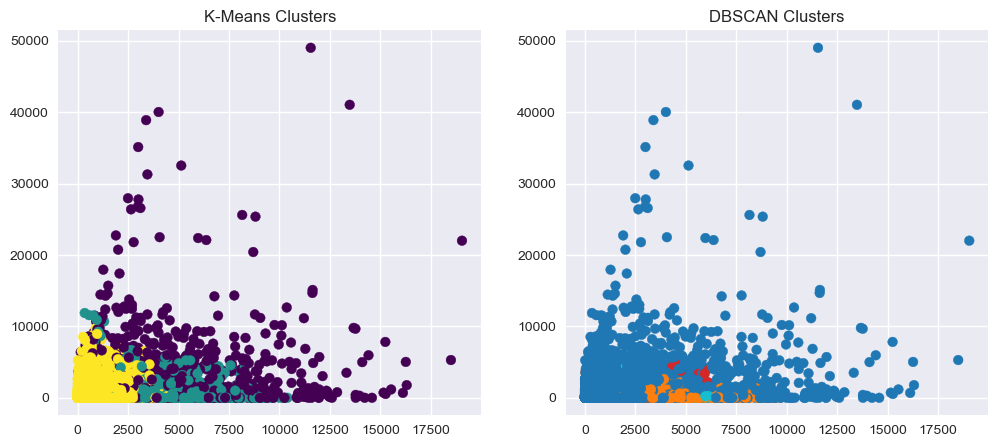

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KMeans
axes[0].scatter(
    df_selected_feat['BALANCE'],
    df_selected_feat['PURCHASES'],
    c=kmeans_labels,
    cmap='viridis'
)
axes[0].set_title('K-Means Clusters')

# DBSCAN
axes[1].scatter(
    df_selected_feat['BALANCE'],
    df_selected_feat['PURCHASES'],
    c=dbscan_labels,
    cmap='tab10'
)
axes[1].set_title('DBSCAN Clusters')

plt.show()

---
- The two plots are not the same but appear similar because K-means assigns every point to a cluster, and DBSCAN groups based on density and can label noise. Because most points are concentrated in one area, DBSCAN forms a large cluster, making both plots look similar.
---

**3: Metrics Table**

In [55]:
mask = dbscan_labels != -1

metrics = pd.DataFrame({
    'Algorithm': ['KMeans', 'DBSCAN'],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled[mask], dbscan_labels[mask]) if len(set(dbscan_labels[mask])) > 1 else None
    ],
    'Num Clusters': [
        len(set(kmeans_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ]
})

metrics

,Algorithm,Silhouette Score,Num Clusters
0,KMeans,0.550691,3
1,DBSCAN,0.342706,14


---
- K-Means has a higher silhouette score, which is indicative of it being defined better and more separated. DBSCAN, on the other hand, did produce more clusters but a lower silhouette score, which indicates less compact grouping. With this, K-Means performs better for the given dataset; DBSCAN appears to be sensitive to parameters.
---

**4: Cluster size bar chart**

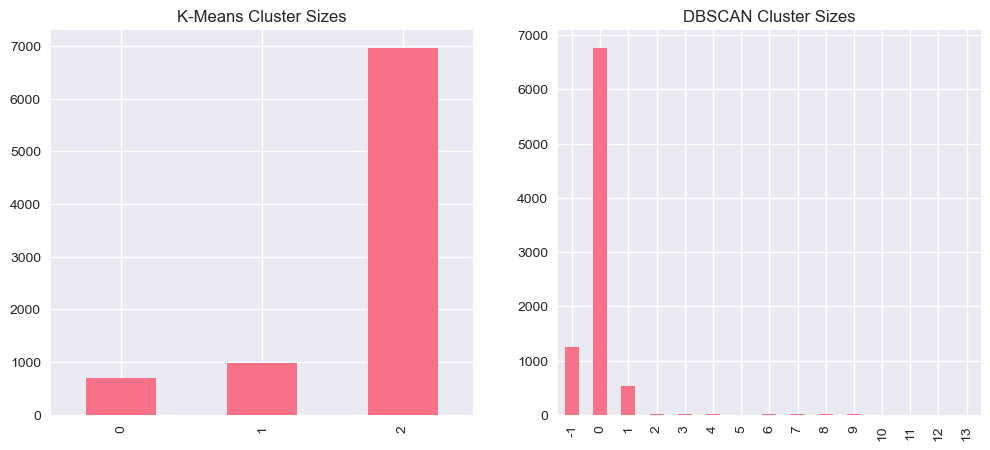

In [56]:
k_counts = pd.Series(kmeans_labels).value_counts().sort_index()
d_counts = pd.Series(dbscan_labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

k_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('K-Means Cluster Sizes')

d_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('DBSCAN Cluster Sizes')

plt.show()

---
- In K-Means, there is a dominant cluster, but it is more balanced compared to DBSCAN, which has one dominant cluster but several small clusters, which include the possible noise points. The reason behind this is that DBSCAN groups most of the data in a dense region, which isolates less dense observations.
---

**5: DBSCAN noise → K-Means mapping**

In [57]:
df_temp = df_selected_feat.copy()
df_temp['KMeans'] = kmeans_labels
df_temp['DBSCAN'] = dbscan_labels

noise_points = df_temp[df_temp['DBSCAN'] == -1]

noise_table = noise_points['KMeans'].value_counts().reset_index()
noise_table.columns = ['KMeans Cluster', 'Noise Count']

noise_table

,KMeans Cluster,Noise Count
0,0,695
1,1,357
2,2,196


---
- Most DBSCAN noise falls on KMeans cluster 0, and the others are spread on clusters 1 and 2 with 357 and 196, respectively. Even if DBSCAN considers these as outliers, K-Means assigns them into groups so points that are labeled by DBSCAN can still belong to a larger cluster in K-Means.
---

**5. Why K-Means is the appropriate algorithm**
-

---
* **Performance Metrics:** K-Means achieves a higher silhouette score and more consistent boundaries than DBSCAN, indicating better-defined and more separated clusters.
* **Structural Fit:** Because the data lacks strongly separated, dense regions, DBSCAN groups most points into one large cluster. K-Means handles this better by cleanly partitioning the data into a fixed number of segments.
* **Handling of Outliers:** DBSCAN classifies unusual customers (e.g., high spenders) as noise. K-Means forces every customer into a cluster, ensuring no actionable data is excluded from marketing analysis.
* **Practical Usability:** K-Means offers stable cluster sizes and clear interpretation, making it much easier to design targeted campaigns and personalized promotions.
* **Conclusion:** K-Means is the superior choice for this dataset because marketing and customer service decisions rely heavily on stability and total market segmentation.
---

**6. References**
-

---
<p style="margin-left: 40px; text-indent: -40px;">DeepSeek AI. (2026). DeepSeek – Assistance for coding, debugging, explaining, and structure
<br>https://www.deepseek.com

<p style="margin-left: 40px; text-indent: -40px;">  OpenAI. (2026). ChatGPT (GPT-5.3) – Assistance for coding, debugging, explaining, and structure
<br> https://chat.openai.com

<p style="margin-left: 40px; text-indent: -40px;">Grammarly Inc. (2026). Grammarly – Assistance for grammar checking and improving writing clarity.
<br>https://www.grammarly.com

<p style="margin-left: 40px; text-indent: -40px;">QuillBot Inc. (2026). QuillBot – Assistance for improving sentence and writing clarity.
<br>https://quillbot.com

---